# T1 — Environment, Data Acquisition, and Exploratory Data Analysis

**Objective:** Load and explore the Customer Analytics dataset, perform a data quality audit, produce visualisations, and save a cleaned version for downstream tasks.

**Required inputs:** `../data/raw/customers_ml.csv`  
**Outputs produced:** `../data/cleaned.csv`, figures saved to `../reports/`

## 1. Environment Setup

All dependencies are listed in `requirements.txt` at the repo root. Install with:
```
pip install -r requirements.txt
```

In [1]:
# ── Constants ──────────────────────────────────────────────────────────────
RAW_DATA_PATH   = "../data/raw/customers_ml.csv"
CLEANED_PATH    = "../data/cleaned.csv"
REPORTS_DIR     = "../reports/"
RANDOM_STATE    = 42

import os
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs("../data", exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Dataset Description

**Dataset:** Customer Analytics Dataset  
**Source:** Derived from the public *Customers-1000* sample dataset (Kaggle), enriched with synthetic behavioural and financial features for ML purposes.  
**License:** CC0 (Public Domain)  

**Description:** The dataset contains 1 000 customer records with demographic attributes (age, country, region), financial indicators (annual income, CLV), purchase behaviour (number of purchases, average purchase value, spending score), and engagement metrics (email open rate, website visits, mobile app usage). The target variables are:
- **CLV** (Customer Lifetime Value) — a continuous target for regression.
- **Churn** — a binary flag indicating whether the customer has churned, used for classification tasks.

## 3. Load Dataset & Structural Overview

In [3]:
RAW_DATA_PATH = r"C:\Users\User\Downloads\MLA_midterm\customers_ml.csv"
df = pd.read_csv(RAW_DATA_PATH)

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names and data types:")
print(df.dtypes)
df.head()

Shape: 1000 rows × 20 columns

Column names and data types:
Index                         int64
First Name                      str
Last Name                       str
Company                         str
City                            str
Country                         str
Age                           int64
Annual_Income               float64
Spending_Score                int64
Years_as_Customer             int64
Num_Purchases                 int64
Avg_Purchase_Value          float64
Num_Complaints                int64
Email_Opens_Rate            float64
Website_Visits_Per_Month      int64
Has_Mobile_App                int64
Preferred_Channel               str
Region                          str
CLV                         float64
Churn                         int64
dtype: object


,Index,First Name,Last Name,Company,City,Country,Age,Annual_Income,Spending_Score,Years_as_Customer,Num_Purchases,Avg_Purchase_Value,Num_Complaints,Email_Opens_Rate,Website_Visits_Per_Month,Has_Mobile_App,Preferred_Channel,Region,CLV,Churn
0,1,Andrew,Goodman,Stewart-Flynn,Rowlandberg,Macao,56,22871.07,58,13,28,127.56,3,0.2826,11,1,Store,South,5220.82,0
1,2,Alvin,Lane,"Terry, Proctor and Lawrence",Bethside,Papua New Guinea,69,59069.27,4,3,20,22.14,1,0.2414,7,0,Online,North,2155.93,0
2,3,Jenna,Harding,Bailey Group,Moniquemouth,China,46,39872.99,4,11,22,416.28,1,0.2575,9,1,Online,South,4368.64,0
3,4,Fernando,Ford,Moss-Maxwell,Leeborough,Macao,32,26554.93,20,6,19,65.06,4,0.1504,6,0,Online,East,2828.83,1
4,5,Kara,Woods,Mccarthy-Kelley,Port Jacksonland,Nepal,60,42068.54,10,2,27,88.63,0,0.0266,6,1,Store,West,2162.48,0


In [4]:
# Feature descriptions
feature_descriptions = {
    "Index":                    "Row identifier",
    "First Name":               "Customer first name",
    "Last Name":                "Customer last name",
    "Company":                  "Employer / associated company",
    "City":                     "City of residence",
    "Country":                  "Country of residence",
    "Region":                   "Sales region (North/South/East/West)",
    "Age":                      "Customer age in years",
    "Annual_Income":            "Yearly income in USD",
    "Spending_Score":           "Internal score 1–100 measuring purchase propensity",
    "Years_as_Customer":        "Tenure in years",
    "Num_Purchases":            "Total number of completed purchases",
    "Avg_Purchase_Value":       "Mean transaction value in USD",
    "Num_Complaints":           "Count of logged complaints",
    "Email_Opens_Rate":         "Fraction of marketing emails opened (0–1)",
    "Website_Visits_Per_Month": "Average monthly website visits",
    "Has_Mobile_App":           "Binary: 1 if customer uses the mobile app",
    "Preferred_Channel":        "Preferred shopping channel",
    "CLV":                      "Customer Lifetime Value in USD (regression target)",
    "Churn":                    "Binary: 1 if customer churned (classification target)",
}

pd.DataFrame.from_dict(feature_descriptions, orient="index", columns=["Description"])

,Description
Index,Row identifier
First Name,Customer first name
Last Name,Customer last name
Company,Employer / associated company
City,City of residence
Country,Country of residence
Region,Sales region (North/South/East/West)
Age,Customer age in years
Annual_Income,Yearly income in USD
Spending_Score,Internal score 1–100 measuring purchase propen...


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
First Name,1000,536,Trevor,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,1000,622,Waters,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,1000,992,Cherry and Sons,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,983,New Yolanda,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1000,240,Liechtenstein,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,43.819,14.99103,18.0,31.0,44.0,56.0,69.0
Annual_Income,1000.0,NaN,NaN,NaN,56283.17549,19447.535068,15000.0,42763.2875,56076.71,68709.405,107647.64
Spending_Score,1000.0,NaN,NaN,NaN,49.673,28.247336,1.0,25.0,48.0,73.0,100.0
Years_as_Customer,1000.0,NaN,NaN,NaN,7.345,3.955708,1.0,4.0,7.0,11.0,14.0


## 4. Data Quality Audit

In [6]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None found — dataset is complete.")

# Duplicates
n_dup = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dup}")

# Churn distribution
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"Churn rate: {df['Churn'].mean():.1%}")

Missing values per column:
None found — dataset is complete.

Duplicate rows: 0

Churn distribution:
Churn
0    814
1    186
Name: count, dtype: int64
Churn rate: 18.6%


In [7]:
# Outlier detection using Z-score for numeric columns
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["Index", "Churn", "Has_Mobile_App"]]

z_scores = np.abs(stats.zscore(df[numeric_cols]))
outlier_counts = (z_scores > 3).sum(axis=0)
print("Outliers (|Z| > 3) per feature:")
print(outlier_counts)

Outliers (|Z| > 3) per feature:
[ 0  0  0  0  3 13  5  2  3  0]


**Data quality decisions:**
- **No missing values** — no imputation required.
- **No duplicate rows** — no row removal required.
- **Outliers in `Avg_Purchase_Value` and `Annual_Income`** are present but represent legitimately high-value customers; they are **kept** as they carry meaningful signal for CLV prediction. Capping would artificially reduce model variance for this business-critical segment.
- **`Index`, `First Name`, `Last Name`, `Company`, `City`, `Country`** columns are identifiers or high-cardinality text with no predictive value — they will be **dropped** before saving `cleaned.csv`.

In [8]:
# Apply fixes
drop_cols = ["Index", "First Name", "Last Name", "Company", "City", "Country"]
df_clean = df.drop(columns=drop_cols).copy()

print(f"Cleaned shape: {df_clean.shape}")
print(df_clean.dtypes)

Cleaned shape: (1000, 14)
Age                           int64
Annual_Income               float64
Spending_Score                int64
Years_as_Customer             int64
Num_Purchases                 int64
Avg_Purchase_Value          float64
Num_Complaints                int64
Email_Opens_Rate            float64
Website_Visits_Per_Month      int64
Has_Mobile_App                int64
Preferred_Channel               str
Region                          str
CLV                         float64
Churn                         int64
dtype: object


## 5. Exploratory Visualisations

### Q1: What is the distribution of Customer Lifetime Value?

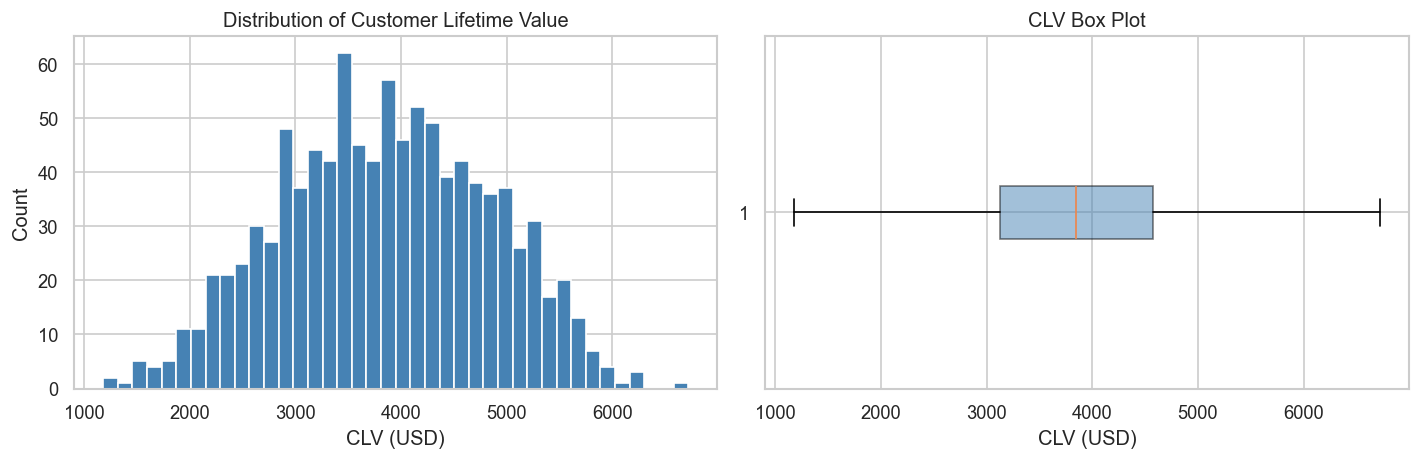

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean["CLV"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("CLV (USD)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Customer Lifetime Value")

axes[1].boxplot(df_clean["CLV"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.5))
axes[1].set_xlabel("CLV (USD)")
axes[1].set_title("CLV Box Plot")

plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig1_clv_distribution.png")
plt.show()

### Q2: Which features correlate most strongly with CLV?

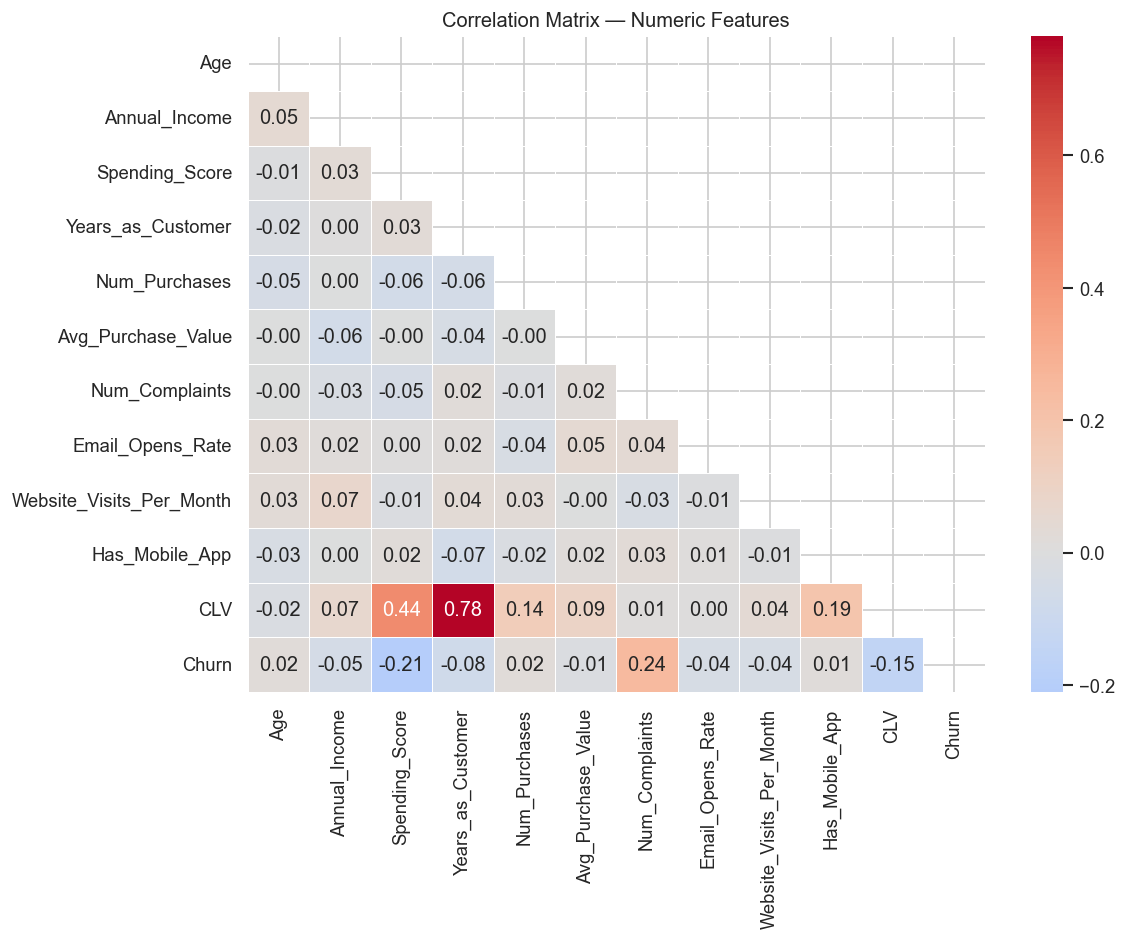

In [10]:
num_feats = df_clean.select_dtypes(include="number").columns
corr_matrix = df_clean[num_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig2_correlation_heatmap.png")
plt.show()


### Q3: Do churned customers differ from retained customers in income and spending score?

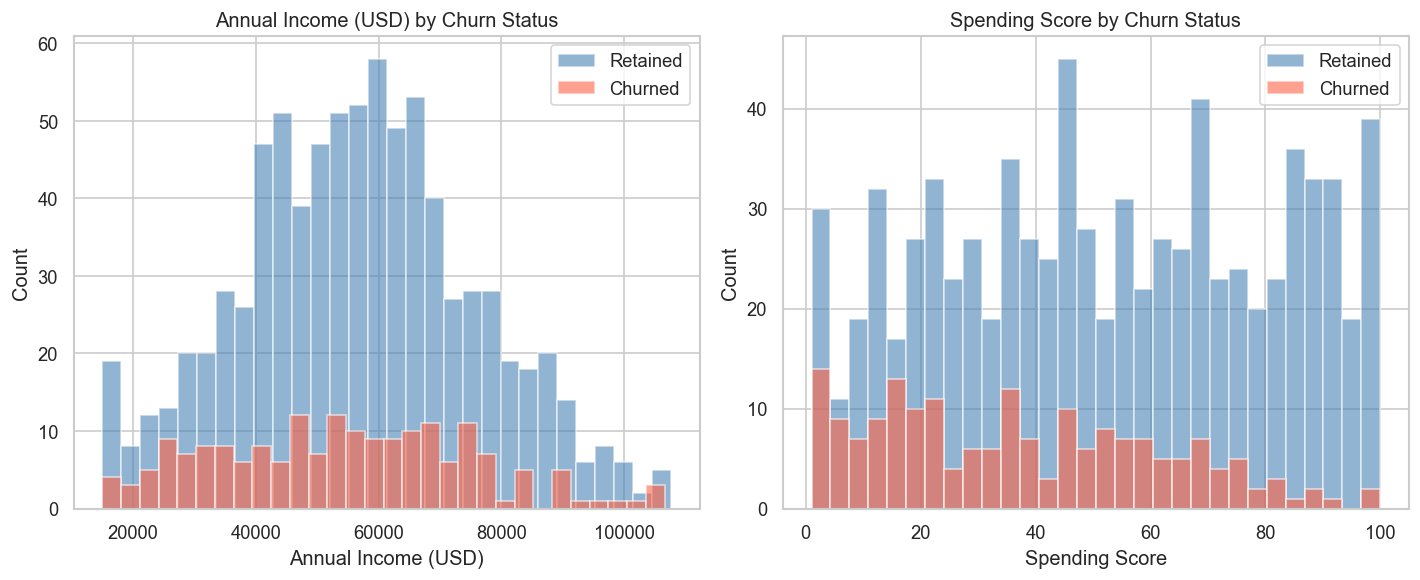

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(axes,
                           ["Annual_Income", "Spending_Score"],
                           ["Annual Income (USD)", "Spending Score"]):
    for churn_val, color, lbl in [(0, "steelblue", "Retained"), (1, "tomato", "Churned")]:
        subset = df_clean[df_clean["Churn"] == churn_val][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=lbl, edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"{label} by Churn Status")
    ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig3_churn_vs_income_spending.png")
plt.show()

### Q4: How does average CLV differ across sales regions and preferred channels?

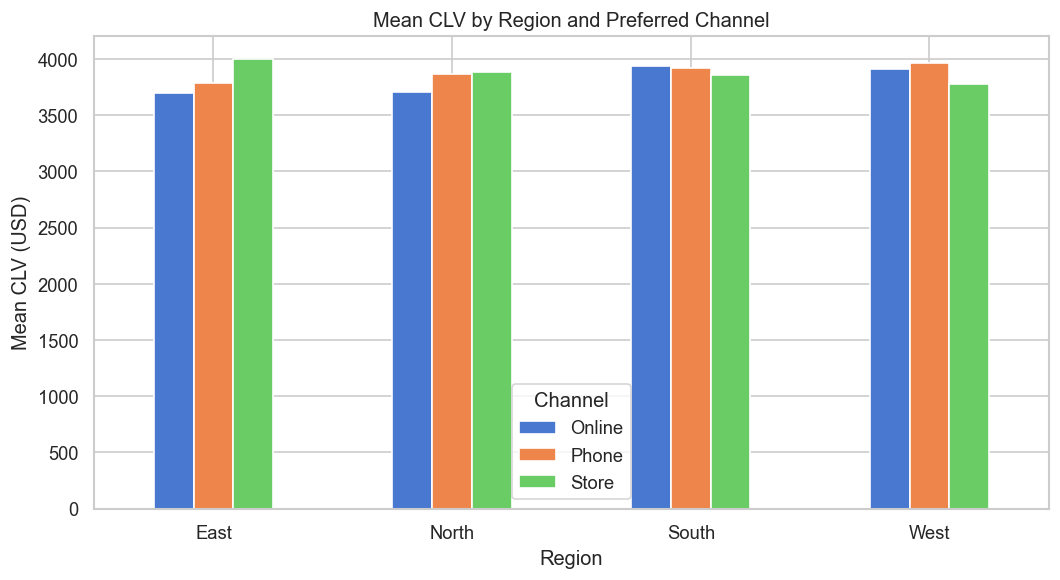

In [12]:
pivot = df_clean.groupby(["Region", "Preferred_Channel"])["CLV"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_xlabel("Region")
ax.set_ylabel("Mean CLV (USD)")
ax.set_title("Mean CLV by Region and Preferred Channel")
ax.legend(title="Channel")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig4_clv_region_channel.png")
plt.show()

### Q5: What is the relationship between number of complaints, tenure, and churn?

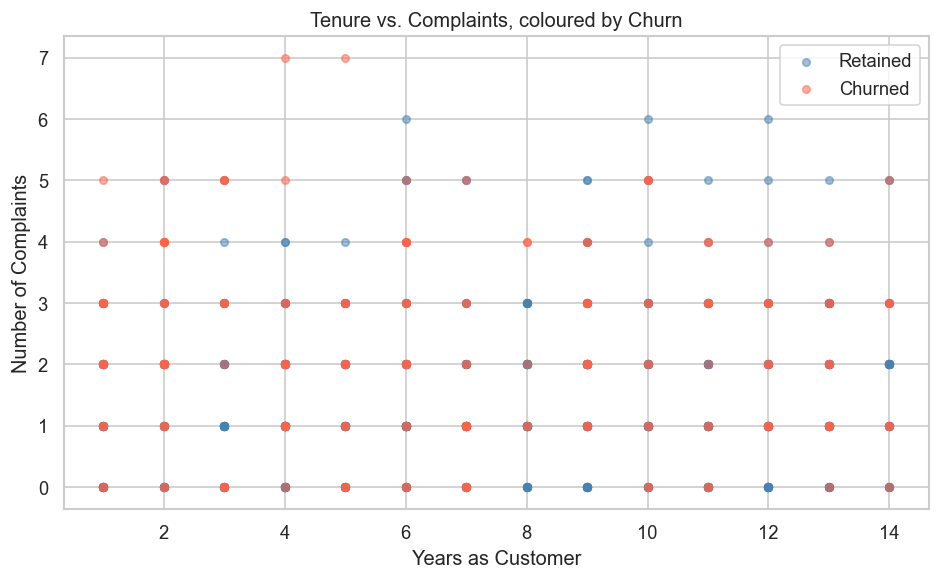

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {0: "steelblue", 1: "tomato"}
for churn_val, color in colors.items():
    subset = df_clean[df_clean["Churn"] == churn_val]
    label = "Churned" if churn_val == 1 else "Retained"
    ax.scatter(subset["Years_as_Customer"], subset["Num_Complaints"],
               alpha=0.5, c=color, label=label, s=20)

ax.set_xlabel("Years as Customer")
ax.set_ylabel("Number of Complaints")
ax.set_title("Tenure vs. Complaints, coloured by Churn")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig5_tenure_complaints_churn.png")
plt.show()

## 6. Save Cleaned Dataset

In [14]:
df_clean.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset → {CLEANED_PATH}")
print(f"Final shape: {df_clean.shape}")

Saved cleaned dataset → ../data/cleaned.csv
Final shape: (1000, 14)


## 7. Summary (150–200 words)

The Customer Analytics dataset contains 1 000 records with 14 usable features after removing non-predictive identifiers. The data is remarkably clean — no missing values or duplicate rows were found, which is uncommon in real-world datasets and may reflect the synthetic enrichment process.

The most striking pattern is the strong positive correlation between `Spending_Score`, `Years_as_Customer`, `Num_Purchases`, and the target `CLV` — customers who shop more frequently and score highly on spending propensity are substantially more valuable over their lifetime. `Annual_Income` shows moderate correlation with CLV, suggesting income alone is not a reliable proxy for value.

Regarding churn (~19% of customers), the scatter plot reveals that churned customers tend to cluster among those with higher complaint counts and shorter tenures — a pattern consistent with the hypothesis that early-stage dissatisfaction drives attrition.

Surprising finding: CLV differences across regions and channels are relatively small, implying that individual behavioural metrics matter more than geography or shopping channel.

Open questions for modelling: Can we predict CLV accurately from behavioural features alone? Is the complaint–churn relationship strong enough for classification after controlling for tenure and income?